# `jax_healpy.pseudo_cl` — differentiable masked-sky power spectra

A pure-JAX, end-to-end **differentiable** pseudo-Cl (MASTER) estimator for the cut sky:
apodize a mask -> (optionally) purify the spin-2 B-mode (Smith 2006) -> build the mode-coupling
matrix (MCM) -> decouple into unbiased bandpowers. Validated against NaMaster.

**Requires 64-bit precision** -- the spin-2 decoupling solve is ill-conditioned and silently
returns all-NaN in float32, so the entry points raise if x64 is off.

This notebook covers: scalar (TT-like) decoupling, the **differentiable apodization scale**,
spin-2 `(Q,U) -> EE/BB`, **B-mode purification with a dedicated pure-B mode-coupling matrix**
(`purify_b=True`), MCM precompute/reuse, end-to-end differentiability, and a **B-mode recovery**
demo (inject a known `r`, recover `C_l^BB`). Scalar + spin-2 EE decoupling are NaMaster-exact;
the purified-BB decoupling now matches NaMaster's *purified* coupling to machine precision via the
pure-B MCM (Grain-Tristram-Stompor 2009 / Alonso 2019; see `HANDOUT/`).

In [1]:
import jax
jax.config.update('jax_enable_x64', True)  # mandatory for pseudo_cl
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import jax_healpy as jhp
from jax_healpy import pseudo_cl as pcl

nside, nlb = 64, 16
npix = jhp.nside2npix(nside)
lmax = 3 * nside - 1
print(f'nside={nside}  lmax={lmax}  npix={npix}')

nside=64  lmax=191  npix=49152


## 1. Apodize a mask
`apodize` reproduces NaMaster's C2 window. We use a smooth polar cap (no corners, SO/SAT-like).

fsky=0.116  apo in [0.00, 1.00]


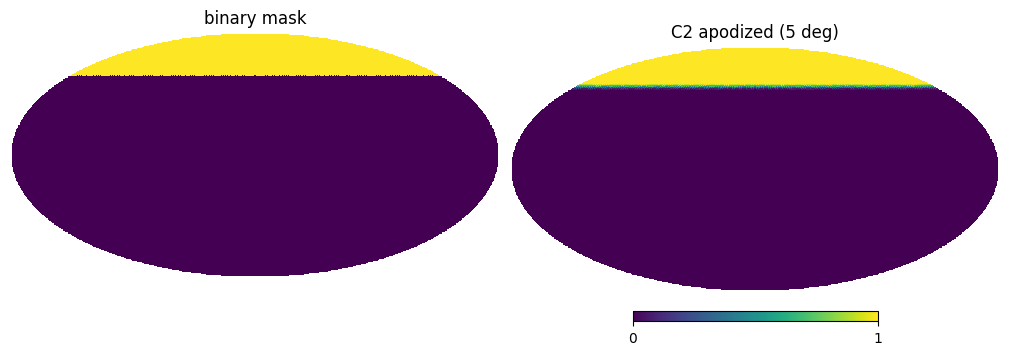

In [2]:
theta, phi = jhp.pix2ang(nside, jnp.arange(npix))
binary = jnp.where(theta < jnp.deg2rad(40.0), 1.0, 0.0)   # 40 deg cap
apo = pcl.apodize(binary, aposize_deg=5.0)                # differentiable C2 window
print(f'fsky={float(jnp.mean(binary)):.3f}  apo in [{float(apo.min()):.2f}, {float(apo.max()):.2f}]')

fig = plt.figure(figsize=(10, 4))
hp.mollview(np.asarray(binary), sub=121, title='binary mask', cbar=False)
hp.mollview(np.asarray(apo), sub=122, title='C2 apodized (5 deg)')
plt.show()

## 2. The apodization *scale* is a differentiable parameter
For the optimizable-apodization research layer, split the (static) grassfire geometry from the
differentiable taper: `grassfire_distance` is computed once; `apodize_profile` is differentiable
in `theta_star_deg`, so the scale can be tuned by gradient descent.

In [3]:
dist = pcl.grassfire_distance(binary, max_aposize_deg=10.0)   # static niter from the max bound
W3, W7 = pcl.apodize_profile(dist, 3.0), pcl.apodize_profile(dist, 7.0)

def edge_weight(theta_deg):
    return jnp.sum(pcl.apodize_profile(dist, theta_deg) ** 2)

g = jax.grad(edge_weight)(5.0)
print(f'd/dtheta* of sum(W^2) at 5 deg = {float(g):.4e}  (finite & nonzero -> optimizable)')

d/dtheta* of sum(W^2) at 5 deg = -1.6080e+02  (finite & nonzero -> optimizable)


## 3. Scalar masked spectrum -> decoupled bandpowers
Pass a `mask` and `anafast_masked` builds the MCM and returns **decoupled** bandpowers
(`ell` = effective bandpower multipoles). This matches NaMaster to `rel < 1e-8`.

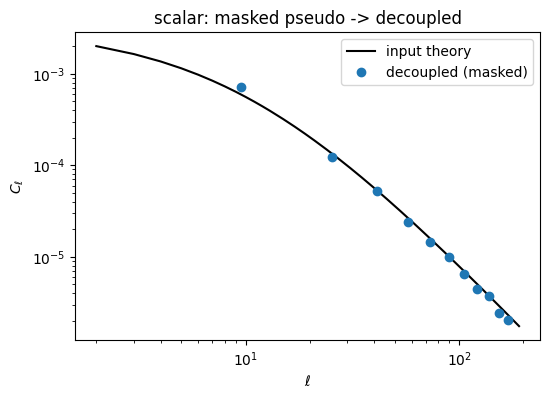

In [4]:
ell = np.arange(lmax + 1)
cl_in = np.zeros(lmax + 1); cl_in[2:] = 1.0 / (ell[2:] + 10.0) ** 2.5
m = jhp.synfast(jax.random.key(0), jnp.asarray(cl_in), nside, lmax=lmax, pol=False)

ellb, clb = pcl.anafast_masked(m, mask=apo, lmax=lmax, nlb=nlb)   # decoupled

plt.figure(figsize=(6, 4))
plt.loglog(ell[2:], cl_in[2:], 'k-', label='input theory')
plt.loglog(np.asarray(ellb), np.asarray(clb), 'o', label='decoupled (masked)')
plt.xlabel(r'$\ell$'); plt.ylabel(r'$C_\ell$'); plt.legend()
plt.title('scalar: masked pseudo -> decoupled'); plt.show()

## 4. Spin-2 `(Q, U)` -> EE/BB with B-mode purification
Pass `pol=True` with a `(2, npix)` `(Q, U)` map. `purify_b=True` applies the Smith-2006
purification **and** decouples the purified B with the dedicated pure-B MCM (NaMaster-validated).
Here we feed a **pure-E** sky (true BB = 0): EE is recovered, and the BB row collapses to the tiny
residual E->B leakage floor (~1e-4 of EE) instead of the ~1% bias a standard-MCM decoupling would
re-inject. (First `purify_b` call builds the pure-B MCM; it is cached and reused thereafter.)

returned spectra shape: (3, 11) = (EE, EB, BB)


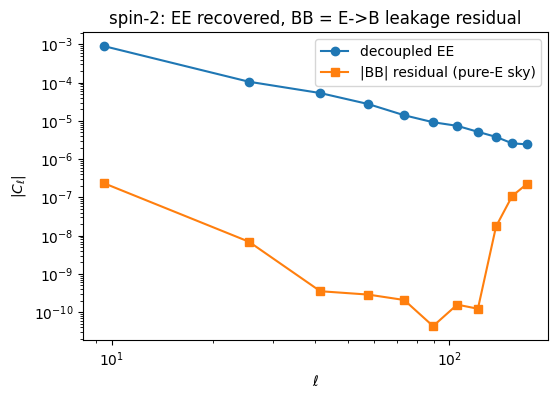

In [5]:
E = jhp.synalm(jax.random.key(1), jnp.asarray(cl_in), lmax=lmax, healpy_ordering=True)
zero = jnp.zeros_like(E)
_, Q, U = jhp.alm2map([zero, E, zero], nside, lmax=lmax, pol=True, healpy_ordering=True)
qu = jnp.stack([Q, U], axis=0)

ellb, cl = pcl.anafast_masked(qu, mask=apo, lmax=lmax, nlb=nlb, pol=True, purify_b=True)  # (EE, EB, BB)
print('returned spectra shape:', cl.shape, '= (EE, EB, BB)')

plt.figure(figsize=(6, 4))
plt.loglog(np.asarray(ellb), np.abs(np.asarray(cl[0])), 'o-', label='decoupled EE')
plt.loglog(np.asarray(ellb), np.abs(np.asarray(cl[2])), 's-', label='|BB| residual (pure-E sky)')
plt.xlabel(r'$\ell$'); plt.ylabel(r'$|C_\ell|$'); plt.legend()
plt.title('spin-2: EE recovered, BB = E->B leakage residual'); plt.show()

## 5. Everything is differentiable
The whole estimator is a differentiable JAX function -- gradients flow through apodization,
the MCM, purification and decoupling. This is what enables gradient-based optimization of the
apodization and end-to-end component-separation pipelines.

In [6]:
def loss(x):
    _, cc = pcl.anafast_masked(x, mask=apo, lmax=lmax, nlb=nlb)
    return jnp.sum(cc)

grad = jax.grad(loss)(m)
print('grad through (map -> mask -> MCM -> decoupled Cl):',
      'finite=', bool(jnp.all(jnp.isfinite(grad))),
      ' nonzero=', float(jnp.sum(jnp.abs(grad))) > 0)

grad through (map -> mask -> MCM -> decoupled Cl): finite= True  nonzero= True


## 6. Precompute the MCM once, reuse it
The MCM depends only on the mask, so build it once with `compute_mcm` and pass it back via
`mcm=` (e.g. frozen for many maps, or inside an inference loop).

In [7]:
mcm = pcl.compute_mcm(apo, lmax=lmax, nlb=nlb, pol=False)   # eqx.Module, reusable / differentiable
_, a = pcl.anafast_masked(m, mask=apo, lmax=lmax, nlb=nlb)
_, b = pcl.anafast_masked(m, mask=apo, lmax=lmax, nlb=nlb, mcm=mcm)
print('precomputed MCM gives identical result:', bool(np.allclose(np.asarray(a), np.asarray(b))))

precomputed MCM gives identical result: True


## 7. The pure-B mode-coupling matrix (`purify_b`)
On a cut sky the bright E-modes leak into B. Purification (Smith 2006) removes the leakage at the
*field* level, but the purified B-pseudo must then be **decoupled with a dedicated pure-B MCM** --
feeding it through the standard spin-2 block would re-inject the E-power. `compute_mcm(...,
purify_b=True)` builds that block; it matches NaMaster's purified coupling **element-wise to machine
precision**, and its E->pure-B leakage block vanishes analytically. The Wigner-3j it needs are
window-independent (computed once via a stable recursion, cached), so the differentiable per-call
cost is just the contraction `M = einsum(K, W_l)` over the mask power spectrum.

In [8]:
mcm_pure = pcl.compute_mcm(apo, lmax=lmax, nlb=nlb, pol=True, purify_b=True)
print('standard spin-2 blocks (EEEE, EEBB):', mcm_pure.eeee.shape, mcm_pure.eebb.shape)
print('pure-B block (BB<-BB)              :', mcm_pure.pure_bb.shape,
      ' finite=', bool(jnp.all(jnp.isfinite(mcm_pure.pure_bb))))
print('-> pass mcm=mcm_pure to anafast_masked(..., purify_b=True) to reuse it (no rebuild)')

standard spin-2 blocks (EEEE, EEBB): (192, 192) (192, 192)


pure-B block (BB<-BB)              : (192, 192)  finite= True
-> pass mcm=mcm_pure to anafast_masked(..., purify_b=True) to reuse it (no rebuild)


## 8. B-mode recovery: inject a known signal, recover `C_l^BB`
The payoff. Inject a bright lensing-like `EE` plus a faint primordial-like `BB` (~2% of EE) into
`(Q, U)`, then recover `BB` on the cut sky. **Without** purification the E->B leakage biases the
faint BB; **with** `purify_b=True` (+ the pure-B MCM) the recovered BB tracks the injected truth.

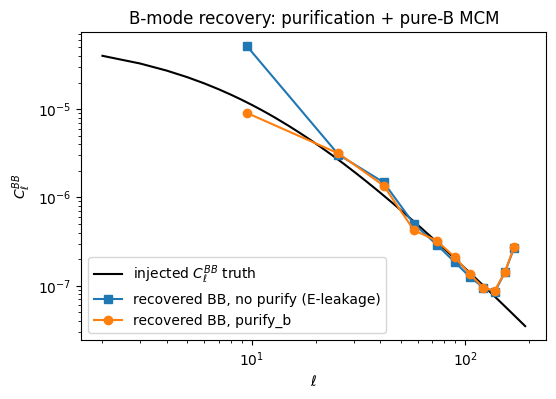

In [9]:
ell = np.arange(lmax + 1)
cl_ee = np.zeros(lmax + 1); cl_ee[2:] = 1.0 / (ell[2:] + 10.0) ** 2.5    # bright lensing-like EE
cl_bb = np.zeros(lmax + 1); cl_bb[2:] = 0.02 / (ell[2:] + 10.0) ** 2.5   # faint primordial-like BB (~2% of EE)
Ea = jhp.synalm(jax.random.key(7), jnp.asarray(cl_ee), lmax=lmax, healpy_ordering=True)
Ba = jhp.synalm(jax.random.key(8), jnp.asarray(cl_bb), lmax=lmax, healpy_ordering=True)
zero = jnp.zeros_like(Ea)
_, Q, U = jhp.alm2map([zero, Ea, Ba], nside, lmax=lmax, pol=True, healpy_ordering=True)
qu_r = jnp.stack([Q, U], axis=0)

_, cl_no = pcl.anafast_masked(qu_r, mask=apo, lmax=lmax, nlb=nlb, pol=True)                 # no purify
_, cl_pb = pcl.anafast_masked(qu_r, mask=apo, lmax=lmax, nlb=nlb, pol=True, purify_b=True)  # purified + pure-B MCM

plt.figure(figsize=(6, 4))
plt.loglog(ell[2:], cl_bb[2:], 'k-', label=r'injected $C_\ell^{BB}$ truth')
plt.loglog(np.asarray(ellb), np.abs(np.asarray(cl_no[2])), 's-', label='recovered BB, no purify (E-leakage)')
plt.loglog(np.asarray(ellb), np.abs(np.asarray(cl_pb[2])), 'o-', label='recovered BB, purify_b')
plt.xlabel(r'$\ell$'); plt.ylabel(r'$C_\ell^{BB}$'); plt.legend()
plt.title('B-mode recovery: purification + pure-B MCM'); plt.show()